<a href="https://colab.research.google.com/github/Innocent-I/Smart-Irrigation-ML/blob/main/notebooks/04_model_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Irrigation ML — Model Validation and Robustness

This notebook investigates the unusually high predictive performance observed in the Smart Irrigation ML project.

## Objectives

1. Examine the relationship between soil moisture and pump status near the decision boundary.
2. Determine how closely pump status follows a simple soil-moisture threshold.
3. Identify observations that do not follow the threshold rule.
4. Evaluate model stability using cross-validation.
5. Compare simple and complex models to determine whether additional model complexity is justified.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [2]:
url = "https://raw.githubusercontent.com/Innocent-I/Smart-Irrigation-ML/main/data/raw/smart_irrigation_data.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (3000, 4)


,Soil Moisture,Temperature,Air Humidity,Pump Data
0,683.802906,29.184908,71.789699,0
1,408.571567,33.707205,77.977391,1
2,659.092074,24.760311,60.776282,1
3,842.929764,32.738515,59.323543,0
4,414.199320,25.692744,66.624914,1


In [3]:
sorted_df = df.sort_values("Soil Moisture")[
    ["Soil Moisture", "Temperature", "Air Humidity", "Pump Data"]
].reset_index(drop=True)

display(sorted_df.head(10))
display(sorted_df.tail(10))

,Soil Moisture,Temperature,Air Humidity,Pump Data
0,314.511016,33.594988,71.554875,1
1,314.511264,20.759009,67.134394,1
2,314.830648,27.979337,62.358731,1
3,314.835832,26.344205,51.718286,1
4,315.068752,35.008054,67.806225,1
5,316.023142,18.862354,41.774132,1
6,316.202371,35.593768,70.764770,1
7,316.238174,27.902510,40.844697,1
8,316.504078,37.790819,62.504613,1
9,316.828602,19.504949,40.048581,1


,Soil Moisture,Temperature,Air Humidity,Pump Data
2990,983.099235,35.235561,80.286797,0
2991,983.365594,23.479596,65.799938,0
2992,983.481274,19.380143,55.398793,0
2993,983.877346,32.714286,65.360615,0
2994,984.177495,37.280737,79.157350,0
2995,984.324371,18.018407,43.293153,0
2996,984.451429,31.077493,67.651408,0
2997,984.511137,25.975422,68.782230,0
2998,984.609603,32.673679,60.303908,0
2999,984.828010,31.232355,75.180225,0


In [4]:
print("Soil Moisture range when Pump is ON:")
print(df.loc[df["Pump Data"] == 1, "Soil Moisture"].agg(["min", "max"]))

print("\nSoil Moisture range when Pump is OFF:")
print(df.loc[df["Pump Data"] == 0, "Soil Moisture"].agg(["min", "max"]))

Soil Moisture range when Pump is ON:
min    314.511016
max    681.693413
Name: Soil Moisture, dtype: float64

Soil Moisture range when Pump is OFF:
min    395.465485
max    984.828010
Name: Soil Moisture, dtype: float64


In [5]:
threshold = 682.58

unexpected_off = df[
    (df["Pump Data"] == 0) &
    (df["Soil Moisture"] < threshold)
].sort_values("Soil Moisture")

print("Pump OFF observations below threshold:", len(unexpected_off))
display(unexpected_off)

Pump OFF observations below threshold: 4


,Soil Moisture,Temperature,Air Humidity,Pump Data
30,395.465485,31.995414,77.418096,0
33,462.162299,34.908466,44.357943,0
313,682.278218,28.920088,52.115397,0
459,682.407454,26.554876,52.276857,0


In [6]:
unexpected_on = df[
    (df["Pump Data"] == 1) &
    (df["Soil Moisture"] >= threshold)
].sort_values("Soil Moisture")

print("Pump ON observations at/above threshold:", len(unexpected_on))
display(unexpected_on)

Pump ON observations at/above threshold: 0


,Soil Moisture,Temperature,Air Humidity,Pump Data


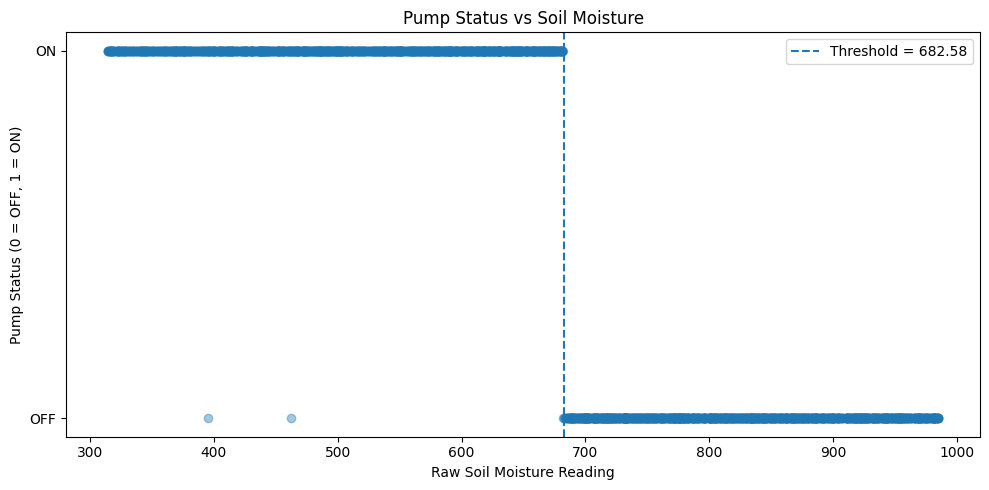

In [7]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["Soil Moisture"],
    df["Pump Data"],
    alpha=0.4
)

plt.axvline(
    x=threshold,
    linestyle="--",
    label=f"Threshold = {threshold:.2f}"
)

plt.xlabel("Raw Soil Moisture Reading")
plt.ylabel("Pump Status (0 = OFF, 1 = ON)")
plt.title("Pump Status vs Soil Moisture")
plt.yticks([0, 1], ["OFF", "ON"])
plt.legend()
plt.tight_layout()
plt.show()

## Threshold Analysis

The analysis revealed a very strong decision boundary between the raw soil-moisture reading and irrigation pump status.

- Pump ON observations ranged from approximately **314.51 to 681.69**.
- Pump OFF observations ranged from approximately **395.47 to 984.83**.
- Using the previously identified threshold of approximately **682.58**, only **4 of 3,000 observations** did not follow the simple threshold rule.
- No Pump ON observations occurred at or above the threshold.

Two of the four exceptions were very close to the threshold, while two occurred substantially below it.

This indicates that pump status in this dataset is almost deterministic from the soil-moisture variable alone. Therefore, the near-perfect performance of the machine learning models should be interpreted cautiously: the classification problem has a very strong single-feature decision boundary.

In [8]:
# Define features and target
X = df[["Soil Moisture", "Temperature", "Air Humidity"]]
y = df["Pump Data"]

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression requires scaling
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

decision_tree = DecisionTreeClassifier(random_state=42)

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Mean Accuracy": scores.mean(),
        "Std Dev": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df.round(4))

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Accuracy,Std Dev
0,Logistic Regression,0.9950,0.9983,1.0000,0.9983,0.9983,0.9980,0.0016
1,Decision Tree,0.9950,1.0000,0.9967,1.0000,0.9983,0.9980,0.0019
2,Random Forest,0.9983,1.0000,1.0000,1.0000,0.9983,0.9993,0.0008


## Cross-Validation Results

To evaluate whether the high model performance was dependent on a single train/test split, 5-fold stratified cross-validation was performed.

The results were:

- **Logistic Regression:** Mean Accuracy = 99.80%, SD = 0.16%
- **Decision Tree:** Mean Accuracy = 99.80%, SD = 0.19%
- **Random Forest:** Mean Accuracy = 99.93%, SD = 0.08%

All three models maintained very high accuracy across the five folds, indicating that the observed predictive performance is stable across different subsets of the dataset.

Random Forest achieved the highest mean accuracy and the lowest variation between folds. However, the improvement over simpler approaches remains very small.

Combined with the threshold analysis, these results indicate that the high predictive performance is primarily explained by the strong relationship between soil moisture and pump status rather than by a complex multivariable pattern.

Therefore, model complexity should be considered alongside interpretability, computational requirements, and expected performance under real-world field conditions.

In [9]:
# Compare Soil Moisture only vs all environmental features

feature_sets = {
    "Soil Moisture Only": df[["Soil Moisture"]],
    "All Features": df[["Soil Moisture", "Temperature", "Air Humidity"]]
}

comparison_results = []

for feature_name, X_subset in feature_sets.items():

    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    scores = cross_val_score(
        rf_model,
        X_subset,
        y,
        cv=cv,
        scoring="accuracy"
    )

    comparison_results.append({
        "Feature Set": feature_name,
        "Mean Accuracy": scores.mean(),
        "Std Dev": scores.std(),
        "Minimum Accuracy": scores.min(),
        "Maximum Accuracy": scores.max()
    })

feature_comparison_df = pd.DataFrame(comparison_results)

display(feature_comparison_df.round(4))

,Feature Set,Mean Accuracy,Std Dev,Minimum Accuracy,Maximum Accuracy
0,Soil Moisture Only,0.9977,0.0017,0.9950,1.0
1,All Features,0.9993,0.0008,0.9983,1.0


## Single-Feature vs Multi-Feature Analysis

To determine whether Temperature and Air Humidity provide substantial additional predictive information, Random Forest was evaluated using two feature sets:

- **Soil Moisture only:** Mean cross-validation accuracy = 99.77%
- **All environmental features:** Mean cross-validation accuracy = 99.93%

Using all three features improved mean accuracy by approximately **0.16 percentage points** and reduced variation across folds.

This indicates that Temperature and Air Humidity provide a small additional predictive contribution. However, Soil Moisture alone is sufficient to explain the vast majority of pump-status predictions in this dataset.

This finding is consistent with the Random Forest feature-importance analysis, where Soil Moisture accounted for approximately **97.8%** of total feature importance.

## Overall Validation Conclusion

The validation experiments show that:

1. Pump status is strongly associated with a soil-moisture decision boundary.
2. Only 4 of 3,000 observations violate the approximate 682.58 threshold rule.
3. All machine learning models maintain approximately 99.8–99.9% mean accuracy under 5-fold stratified cross-validation.
4. Random Forest achieved the highest cross-validation performance at approximately 99.93%.
5. Soil Moisture alone achieved approximately 99.77% accuracy with Random Forest.
6. Adding Temperature and Air Humidity produced only a small improvement.

These findings suggest that the exceptionally high model performance is primarily driven by the structure of this dataset rather than evidence that a complex machine learning model is required.

For deployment in a simple irrigation controller, a calibrated soil-moisture threshold may therefore be preferable because of its simplicity and interpretability. More advanced machine learning would be better justified when incorporating additional real-world factors such as rainfall, weather forecasts, crop characteristics, soil properties, temporal sensor patterns, and remote-sensing observations.